# Data as Counter-Narrative: W.E.B. Du Bois and the 1900 Paris Exposition

**Module 3 of 3** | Critical Thinking with Data

Author: Emett Mendel

**Estimated time:** 2-3 class periods (approx. 150-200 minutes total)

---

> *"Those are aggregate counts. Things aggregate counts cannot show: a single face. A single name. A single moment of refusal — the woman who fought, the adolescent who ran away, the parent who petitioned the courts. A single story of what a survivor said about her own body afterwards. The data is silent where the lives were loudest."*
> — closing passage, Module 2

Module 2 ended with that silence. Module 3 is what it looks like when someone refuses to leave the silence alone.

In **1900** — the same year Karl Pearson published the chi-squared test you used in Module 2 — **W. E. B. Du Bois** and a team of students at Atlanta University sent **sixty-three hand-drawn data visualizations** across the Atlantic to the Exposition Universelle in Paris. They were part of the *American Negro Exhibit*. They were also an argument: that Black Americans were not a population to be counted from the outside for European scientists to rank, but a community that could account for itself — visually, mathematically, narratively. The exhibit won seventeen medals.

In Module 1, you worked with data Galton collected *about* people in his Anthropometric Laboratory. In Module 2, you worked with data California *collected about* people it was sterilizing. In Module 3, you will work with data Du Bois and his students produced *with* and *from* the community the data describes.

This notebook asks: *can marginalized communities produce data on their own terms?* — and it uses the same Python you've been using all semester to recreate Du Bois's Plate 25, watch his argument evaporate when rendered in matplotlib defaults, place his plate next to an eugenic pedigree chart from the same decade, and then produce a counter-visualization of your own.


---

## Learning Objectives

By the end of this module, you will be able to:

1. Explain how Du Bois's "insider citizen researcher" methodology inverted the power dynamic of top-down state data collection that Modules 1 and 2 documented.
2. Read Du Bois's design choices (color, scale, spiral composition, annotation) as **argument**, not decoration.
3. Recreate Plate 25 (*Assessed Value of Household and Kitchen Furniture Owned by Georgia Negroes*) in Python using an authenticated Du Bois color palette and an Archimedean spiral layout.
4. Demonstrate the **Plate 25 Defaults Inversion**: render identical numerical data with matplotlib defaults and articulate how the rhetorical force changes.
5. Compare Du Bois's counter-narrative to a eugenic propaganda chart from the same era (the Kallikak Family pedigree, 1912) and name the rhetorical moves each makes.
6. Produce a single counter-visualization of Module 1 or Module 2 data "in the Du Bois style," and defend the design choices in a 100-word artist's statement.
7. Complete the **HCE Audit** — the course's four-question critical reading protocol — on both Du Bois's original plate and your own recreation.
8. Distinguish data produced **about** a community, **with** a community, and **by** a community, and name what each modality structurally reveals and conceals.


---

## Table of Contents

1. [Part 1: 1900 — The Year of the Chi-Squared and the Paris Exposition](#part-1)
2. [Part 2: The Data and the Exhibit](#part-2)
3. [Part 3: Plate 25 in Du Bois's Hand — Recreation](#part-3)
4. [Part 4: The Plate 25 Defaults Inversion](#part-4)
5. [Part 5: Counter-Narrative vs. Eugenic Propaganda — A Side-by-Side](#part-5)
6. [Part 6: Your Own Counter-Visualization](#part-6)
7. [HCE Audit: Classification, Performativity, Representation, Agency](#hce-audit)
8. [Synthesis, Final Project Brief, and Reflection](#synthesis)

---

<div style="background-color:#fff3cd; border-left: 4px solid #856404; padding: 12px 16px; margin: 10px 0;">
<b>Content note.</b> This module places Du Bois's affirming counter-narrative next to an eugenic pedigree chart (the Kallikak Family, 1912) that used classifications like "feebleminded" to argue for the hereditary inferiority of specific families. The Kallikak chart is shown for educational comparison; its terminology and claims are presented because the historical record uses them. This is the third module of a course that has worked with the eugenic origins of statistics (Module 1) and California's forced sterilization program (Module 2); the through-line to this chart is direct. An opt-out alternative is available from your teacher.
</div>


---

### Setup

Run the cell below to load the Python libraries we'll use and to configure plot styling.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Otter (Berkeley autograder) — keep for submission compatibility
import otter
generator = otter.Notebook()

# Ensure figures directory exists for saving outputs
os.makedirs('figures', exist_ok=True)

# Plot defaults — we will intentionally override these in Part 3 for Du Bois's palette
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

print('Setup complete.')


Setup complete.


---
<a id="part-1"></a>
## Part 1: 1900 — The Year of the Chi-Squared and the Paris Exposition

In Module 2 you used Karl Pearson's chi-squared test to document California's forced sterilization program. That test was published in 1900. The same year — the exact same twelve months — on a different continent, a thirty-two-year-old sociologist named **W. E. B. Du Bois** was in Atlanta finalizing a collection of hand-drawn data visualizations to send to Paris. Pearson's paper appeared in *Philosophical Magazine* in July 1900. Du Bois's exhibit opened at the Exposition Universelle in April 1900. They never corresponded.

Two men, two continents, two uses of numbers. Pearson's test would quickly become foundational to the inferential statistics that Module 2 used to quantify a racial disparity. Du Bois's plates would sit in the Library of Congress mostly unexamined for a century before being rediscovered in the 2010s. The former was published, cited, and standardized; the latter was admired as craft and ignored as method.

### The Exposition Universelle

The 1900 World's Fair in Paris drew about **50 million visitors** over six months. It was the largest world's fair ever held. Inside was the *Exposition des Nègres d'Amérique* — the American Negro Exhibit — organized by Du Bois, sociologist Thomas J. Calloway, and a team of Atlanta University students. Battle-Baptiste and Rusert describe the exhibit as an argument about what empirical evidence about Black Americans could look like in 1900 if produced from inside the community rather than imposed from outside.

Du Bois and Calloway's team produced approximately sixty-three hand-drawn plates, mostly poster-sized (22×28 inches), in portrait orientation, in colored ink. They drew on US Census records, Atlanta University's original sociological fieldwork, Georgia state and county data, and — most distinctively — what Du Bois called **insider citizen researchers**: members of Black communities across the US who collected data about their own lives.

The exhibit won **seventeen medals**, including two Grand Prix. Du Bois received a personal gold medal. The plates returned to the US and entered the Library of Congress. Then they sat.

### The Insider Citizen Researcher

The methodological innovation Du Bois made — that a community can produce data *about itself*, for purposes of its own choosing, using its own members as the researchers — is the structural inverse of what you saw in Modules 1 and 2.

| Module | Who produced the data | Who the data was about | For whose purpose |
|---|---|---|---|
| 1 (Galton) | Galton, in a paid exhibition booth | Middle/upper-class London families | Galton's eugenic research program |
| 2 (California Sterilization) | State institutional superintendents | People institutionalized by the state | State policy |
| 3 (Du Bois) | Du Bois + Atlanta U. students + insider citizen researchers | Black Americans, especially in Georgia | Black Americans' self-representation at a European exposition |

The third row is what the phrase "counter-narrative" means in practice. The data is not better because it comes from inside; it is *different* because the question *"whose interests does this serve?"* has a different answer.

*Sources: Battle-Baptiste and Rusert, [W.E.B. Du Bois's Data Portraits: Visualizing Black America](https://press.princeton.edu/books/hardcover/9781616897062/w-e-b-du-boiss-data-portraits) (2018); Library of Congress, [African American Photographs Assembled for 1900 Paris Exposition](https://www.loc.gov/collections/african-american-photographs-1900-paris-exposition/).*


---
### Stop and Think
*Take 3 minutes on your own before discussing with anyone.*

**Question 1.1.** In Module 2 you used Pearson's chi-squared test — invented in 1900 — to document a racial disparity in California's forced sterilization program. Du Bois made his plates in 1900. Think about Module 2's closing passage on what aggregate data structurally *cannot* show. What does it mean that two such different uses of data were produced the same year?

**Question 1.2.** Read the three-row table above. Write one sentence, in plain English, explaining the single most important difference between the data Galton collected (Module 1), the data California collected (Module 2), and the data Du Bois produced.

---


---
<a id="part-2"></a>
## Part 2: The Data and the Exhibit

The Library of Congress now hosts high-resolution scans of all sixty-three Du Bois plates at no cost. In 2021, the designer and programmer **Anthony Starks** began the #DuBoisChallenge, an annual public project that has produced machine-readable CSV datasets for most of the plates by manually reading values off the hand-drawn charts. Those CSVs are what we will use in this module.

There is a reconstruction error in the CSVs: values read off a hand-drawn chart are approximate. Starks's team has been rigorous about documenting this. The tradeoff is that we can work with the data in Python at all — an authentic recreation of a hand-drawn plate will always be slightly imprecise compared to the underlying Census data Du Bois's team consulted. You are not retrieving a datum; you are reading an argument.

### Plate 25: Assessed Value of Household and Kitchen Furniture Owned by Georgia Negroes

The plate we will recreate and analyze is **Plate 25**. Its full title (reproduced here in Du Bois's ALL-CAPS convention from the original):

> **ASSESSED VALUE OF HOUSEHOLD AND KITCHEN FURNITURE OWNED BY GEORGIA NEGROES.**

Plate 25 is the spiral that appears on the cover of Battle-Baptiste and Rusert's *Data Portraits*. It is widely considered the most formally daring of Du Bois's plates. It shows six data points — the total assessed value of household and kitchen furniture owned by Black Georgians, every five years from 1875 to 1899. The values grow from about twenty-one thousand dollars to nearly a million and a half.

Here is the data:


In [47]:
plate25 = pd.read_csv('data/plate25_household_furniture.csv')
plate25


,Year,Household Value (Dollars)
0,1875,21186
1,1880,498532
2,1885,736170
3,1890,1173624
4,1895,1322694
5,1899,1434975


A simple table. Six numbers. This is the entire dataset — all of Plate 25, in seven lines of text.

What makes the plate the object it is, is not the data. It is what Du Bois and his team did with the data. That is what Part 3 takes up.

### A Note on What This Plate Does and Does Not Show

Du Bois was making a case *to* a European audience *about* Black economic progress. The plate shows rising furniture value — a proxy for household prosperity, property, stability. What it does not show:

- **Inequality within Black Georgia.** The plate is an aggregate. Some Black Georgians were thriving; many were not.
- **Lynching, voter suppression, labor coercion.** Du Bois wrote about these elsewhere. They are not in this plate.
- **What the furniture itself looked like, or the conditions of the homes it was in.**

These absences are deliberate. Du Bois chose metrics legible to a white European audience to argue for Black human dignity. The choice has been criticized by later scholars as "respectability politics" — metrics that accept the dominant culture's terms of evaluation. The choice has also been defended as strategic: you fight on the terrain you can win on.

You will sit with this tension in the HCE Audit at the end of the notebook.


---
### Pair Discussion
*With a partner, discuss for 5 minutes.*

1. Du Bois's team manually read values off the original hand-drawn plates to create the CSV we just loaded. Module 2 had its own data-reconstruction problem (aggregates published instead of restricted individual records; Spanish-surname proxy for ethnicity). Compare the two reconstruction problems. What is the same? What is different? Which feels more consequential to the analysis, and why?
2. Plate 25 is six numbers. Our Module 1 dataset was 934 rows. Our Module 2 dataset was 17,362 records. Does the size of the dataset change its claim to being "data"? Would six numbers on a hand-drawn chart be taken as seriously as 17,362 records if Du Bois had published them in 1900? Why or why not?
3. Du Bois omitted lynching, voter suppression, and other forms of racial violence from his plates. He wrote about them in his other work (e.g., *The Souls of Black Folk*, 1903). Was this omission strategically wise or ethically compromising? Is it possible to be both?

---


---
<a id="part-3"></a>
## Part 3: Plate 25 in Du Bois's Hand — Recreation

Look at the original plate first. Before you write any code, sit with what Du Bois and his students made.


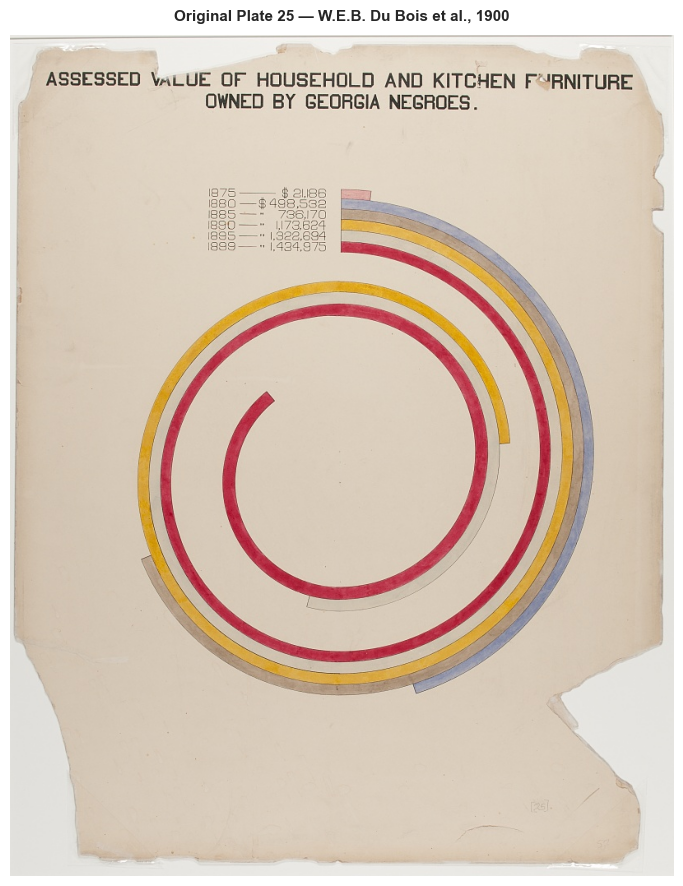

In [48]:
fig, ax = plt.subplots(figsize=(7, 9))
img = mpimg.imread('images/original-plate-25.jpg')
ax.imshow(img)
ax.axis('off')
ax.set_title('Original Plate 25 — W.E.B. Du Bois et al., 1900',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


### Four design choices to notice before we code

1. **The form.** It is a spiral. A bar chart would have flattened the growth from $21,186 in 1875 to $1,434,975 in 1899 — a 67× increase — into a visual whose first bar would have been invisible. A spiral lets the large numbers *wrap around* the chart so small numbers and large numbers both get visual real estate. Du Bois also used this "wrapping" form in Plates 17, 26, and 62. There is a 2020 peer-reviewed paper on the "Du Bois Wrapped Bar Chart" in the ACM CHI conference proceedings — this form is studied seriously as a visualization innovation.

2. **The palette.** Du Bois used bold, solid colors — what we would now call Pan-African (red, gold, green, black) plus warm pastels (pink, tan, brown). No modern matplotlib default produces anything like this. Anthony Starks has documented the exact hex values used; we load them below.

3. **The typography.** All caps. Centered title ending in a period. Sans-serif, hand-lettered. Modern matplotlib titles are none of these.

4. **The annotation.** The original plate has text inside the chart — not in a separate caption below — explaining what the values mean. The text *is* the argument.

Our goal is to reproduce the first three choices closely and the fourth stylistically. Let's start with the palette.


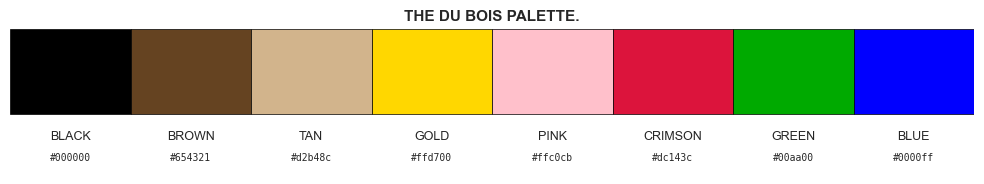

In [49]:
# The authenticated Du Bois color palette, documented by Anthony Starks
# in the Du Bois Data Portraits style guide.
# Hex values from data/dubois-data-portraits/dubois-style.md

DUBOIS_COLORS = {
    'black':   '#000000',
    'brown':   '#654321',
    'tan':     '#d2b48c',
    'gold':    '#ffd700',
    'pink':    '#ffc0cb',
    'crimson': '#dc143c',
    'green':   '#00aa00',
    'blue':    '#0000ff',
}

# Visualize the palette for reference
fig, ax = plt.subplots(figsize=(10, 2))
for i, (name, hex_val) in enumerate(DUBOIS_COLORS.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=hex_val,
                               edgecolor='black', linewidth=0.5))
    ax.text(i + 0.5, -0.3, name.upper(), ha='center', fontsize=9)
    ax.text(i + 0.5, -0.55, hex_val, ha='center', fontsize=7, family='monospace')
ax.set_xlim(0, len(DUBOIS_COLORS))
ax.set_ylim(-0.7, 1)
ax.axis('off')
ax.set_title('THE DU BOIS PALETTE.', fontsize=11, fontweight='bold', family='sans-serif')
plt.tight_layout()
plt.show()


### Building the Spiral

Look closely at the original plate again. Where does each colored band *end*?

Every single one ends at the **top** of the chart — at 12 o'clock. The outermost pink 1875 band is a tiny arc ending at the top. The 1880 band is a longer arc ending at the top, at a slightly smaller radius. The gold 1890 band wraps a full turn, ending at the top. The crimson 1899 band wraps **almost two full turns**, ending at the top at the innermost radius. Trace a vertical line straight up from the center of the chart and you will pass through the endpoint of every single band.

This is the visual signature of Plate 25. Du Bois drew a spiral where each year's band winds at a characteristic slope — starting at its own radius and spiraling inward as it sweeps around. Here is the clever part of the construction:

**Map value to angle directly.** If we set $\theta = 2\pi \cdot \text{value} / X_{\max}$ and also make the radius depend linearly on value, every year's band becomes a sloped line in (value, radius) space — which a polar projection renders as a *spiral*. The slope controls how quickly the spiral winds inward. Small values (1875) cover a small angle and barely move inward; large values (1899) cover most of a full turn and wind considerably.

**The overflow trick.** Values above about 80% of the max (1890, 1895, 1899) get *split* into a main segment (capped at 80% of max) and an **overflow segment** drawn with a steeper slope. This is what lets the crimson 1899 wrap almost *twice* around the center. Smaller values fit comfortably in a single pass; large values need the wrap.

Our implementation below is a Python port of Molly Kuhs's R recreation for the 2025 #DuBoisChallenge (Week 7). Kuhs chose colors that match the original plate more closely than the Starks documented palette:

- **1875:** dusty pink — outermost, tiny arc
- **1880:** steel blue-gray
- **1885:** tan
- **1890:** gold (the first year to trigger the overflow wrap)
- **1895:** light gray
- **1899:** crimson — the hero red wrapping nearly twice at the center

Also: warm parchment background (`#d4c7b6`), dark olive outlines (`#262719`) drawn underneath each colored band, ALL-CAPS title ending in a period, year/value legend in the upper left — zeros rendered as capital O's to match Du Bois's hand-lettering.


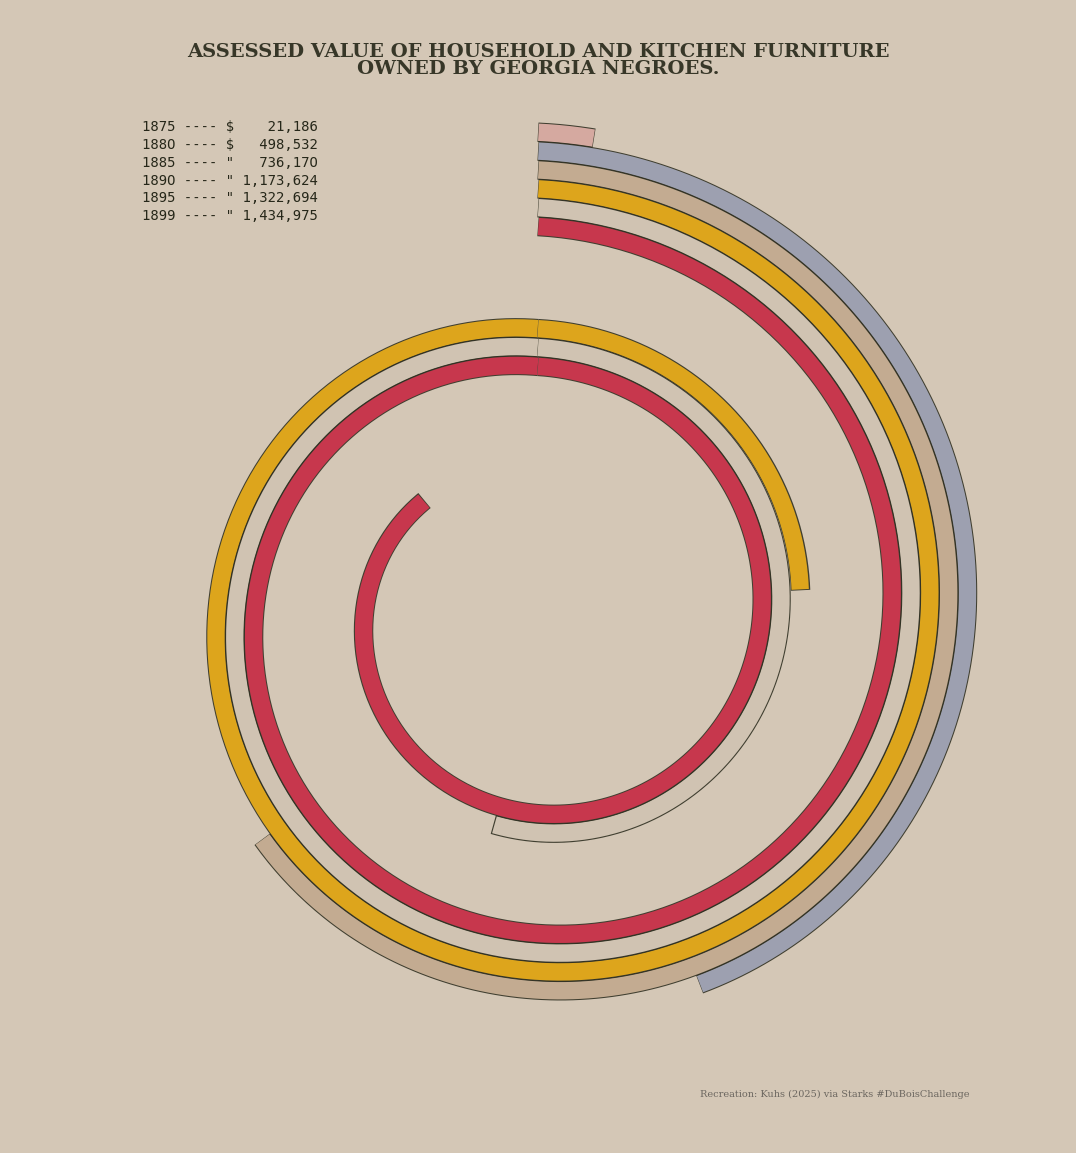

In [ ]:
# ---------------------------------------------------------------------------
# Plate 25 recreation. Porting Molly Kuhs's R implementation for the
# 2025 #DuBoisChallenge (Week 7) to Python. Kuhs's approach renders each
# year as a sloped line in value-space that becomes a spiral under polar
# projection, with an overflow trick for values above 80% of the maximum
# (so 1890, 1895, 1899 wrap a full turn and then some).
# ---------------------------------------------------------------------------

plate25 = pd.read_csv('data/plate25_household_furniture.csv')
# Build a local working frame with Kuhs's short column name; leave `plate25`
# untouched so Part 4's defaults rendering still finds 'Household Value (Dollars)'.
data = plate25.rename(columns={'Household Value (Dollars)': 'hhVal'})[['Year', 'hhVal']].copy()

# Kuhs's colors, tuned to match Du Bois's original plate closely (warmer and
# less saturated than the core DUBOIS_COLORS palette we loaded above).
PLATE25_COLORS = ['#d5a9a0',   # 1875 dusty pink
                  '#9da0b0',   # 1880 steel blue-gray
                  '#c3ab91',   # 1885 tan
                  '#dda51c',   # 1890 gold
                  '#d0c3b2',   # 1895 light gray
                  '#c7374d']   # 1899 crimson

OUTLINE_COLOR = '#262719'       # dark olive-black — the ink outline
BG_COLOR      = '#d4c7b6'       # warm parchment (poster stock)


# ---- label formatting (zeros -> capital O's for the hand-lettered look) ---
def format_val(v):
    return f'{v:,}'.replace('0', 'O')

# Build one monospace-aligned line per row. Uses '$' for the first two rows
# and a ditto mark '"' for the rest (Du Bois convention).
_max_val_width = max(len(format_val(v)) for v in data['hhVal'])
_legend_lines = []
for year, val in zip(data['Year'], data['hhVal']):
    year_str = str(year).replace('0', 'O')
    val_str  = format_val(val).rjust(_max_val_width)
    sep      = '$' if year in (1875, 1880) else '"'
    _legend_lines.append(f'{year_str} ---- {sep} {val_str}')
LEGEND_TEXT = '\n'.join(_legend_lines)


# ---- spiral geometry (mirrors R's dataSpiral block) ----------------------
MAX_CAP = data['hhVal'].max() * 0.8         # 80% of largest value — the overflow threshold
SLOPE   = (10 * 1.25) / (-MAX_CAP - 400_000)
XMAX    = 1_148_200                          # value at which theta = 2π (one full turn)

data['y']     = 10 - np.arange(len(data)) * 1.25            # starting radius for each year
data['xEnd']  = data['hhVal'].clip(upper=MAX_CAP)           # main segment endpoint
data['xEnd2'] = np.where(data['hhVal'] < MAX_CAP,            # overflow (only for 1890/1895/1899)
                          np.nan, data['hhVal'] - MAX_CAP)
data['yEnd']  = SLOPE * data['xEnd'] + data['y']
data['yEnd2'] = (SLOPE * 2.5) * data['xEnd2'] + data['yEnd']  # steeper slope on overflow


def polar_arc(x0, x1, r0, r1, n=400):
    """Sample from (x0, r0) to (x1, r1) and map x -> theta = 2π x / XMAX."""
    xs = np.linspace(x0, x1, n)
    rs = np.linspace(r0, r1, n)
    thetas = 2 * np.pi * xs / XMAX
    return thetas, rs


# ---- figure --------------------------------------------------------------
fig = plt.figure(figsize=(9, 11), facecolor=BG_COLOR)

# Polar axes occupying most of the canvas
ax_p = fig.add_axes([-0.15, -0.03, 1.30, 0.96], projection='polar')
ax_p.set_facecolor('none')
ax_p.set_theta_zero_location('N')   # 0 angle = 12 o'clock (top)
ax_p.set_theta_direction(-1)        # clockwise
ax_p.set_ylim(-22, 13)
ax_p.set_rorigin(-22)
ax_p.set_axis_off()

LW_OUTLINE = 14.0
LW_COLOR   = 12.5

for i, row in data.iterrows():
    color = PLATE25_COLORS[i]

    # --- main segment (value from 0 to min(hhVal, MAX_CAP)) ---
    th, r = polar_arc(0, row['xEnd'] + 200, row['y'], row['yEnd'])
    ax_p.plot(th, r, color=OUTLINE_COLOR, lw=LW_OUTLINE,
              solid_capstyle='butt', alpha=0.85)
    th, r = polar_arc(200, row['xEnd'], row['y'], row['yEnd'])
    ax_p.plot(th, r, color=color, lw=LW_COLOR, solid_capstyle='butt')

    # --- overflow segment (only if hhVal > MAX_CAP) ---
    if np.isnan(row['xEnd2']):
        continue

    if row['Year'] == 1890:
        out_x, out_y = row['xEnd2'] * 10.49 + 900, row['yEnd2'] - 0.98
        col_x, col_y = row['xEnd2'] * 10.5,        row['yEnd2'] - 1
    else:
        out_x, out_y = row['xEnd2'] * 3.5 + 1000, row['yEnd2']
        col_x, col_y = row['xEnd2'] * 3.5,        row['yEnd2']

    th, r = polar_arc(0, out_x, row['yEnd'], out_y)
    ax_p.plot(th, r, color=OUTLINE_COLOR, lw=LW_OUTLINE,
              solid_capstyle='butt', alpha=0.85)
    th, r = polar_arc(0, col_x, row['yEnd'], col_y)
    ax_p.plot(th, r, color=color, lw=LW_COLOR, solid_capstyle='butt')


# ---- title + label overlay (cartesian canvas layered on top) -------------
ax_t = fig.add_axes([0, 0, 1, 1])
ax_t.set_xlim(0, 100)
ax_t.set_ylim(0, 100)
ax_t.set_axis_off()
ax_t.patch.set_alpha(0)

ax_t.text(50, 97,
          'ASSESSED VALUE OF HOUSEHOLD AND KITCHEN FURNITURE\n'
          'OWNED BY GEORGIA NEGROES.',
          ha='center', va='top',
          fontsize=14, color=OUTLINE_COLOR, alpha=0.9,
          fontweight='bold', linespacing=0.95, family='serif')

# Year + value legend, upper-left block, monospace for column alignment
ax_t.text(6, 90, LEGEND_TEXT,
          ha='left', va='top', fontsize=10, family='monospace',
          color=OUTLINE_COLOR, linespacing=1.35)

# Attribution (bottom-right)
ax_t.text(98, 1,
          'Recreation: Kuhs (2025) via Starks #DuBoisChallenge',
          ha='right', va='bottom', fontsize=7, family='serif', alpha=0.6)

plt.savefig('figures/plate25_dubois_style.png', dpi=150,
            facecolor=BG_COLOR, bbox_inches='tight')
plt.show()


### How well did we do?

Look back at the original plate image above. Now look at our recreation. They are not identical. What we reproduced:

- The **spiral form**.
- The **Pan-African + warm palette** (crimson, gold, tan, brown, plus black and pink).
- The **ALL-CAPS centered title ending in a period**.
- The **parchment-toned background**.

What our recreation misses:

- The **hand-lettering** — our title is in matplotlib's default sans-serif, which is too clean.
- The **internal annotation** — Du Bois had explanatory text woven into the spiral's interior. We chose to keep labels minimal for readability.
- The **exact proportions** — Du Bois made rhetorical choices about how thick each band should be (not just proportional to value), choices we flattened into a single mathematical rule.

Those misses are real. They are also part of the point: a "perfect" reproduction would require hand-lettering and editorial discretion that Python does not natively provide. What we got is the **argument structure** — the decision to use a spiral, the decision to use a bold non-default palette, the decision to use ALL-CAPS — reproduced algorithmically.

In Part 4, we will strip all three of these decisions out, render the same six numbers in matplotlib defaults, and see what happens to the argument.


---
<a id="part-4"></a>
## Part 4: The Plate 25 Defaults Inversion

Here is the pedagogical move this module has been building toward.

You will render the **identical six numbers** Du Bois's team had in 1900 — no change to the data, no change to the values, no manipulation — using matplotlib's defaults. No custom palette. No spiral. No Pan-African colors. No ALL-CAPS title. Just `plt.bar(x, y)` with whatever matplotlib gives you.

Then you will compare the two renderings and articulate what changed.

### What you are testing

The claim is that **visualization design is argument**. If it is, then stripping the design choices out of the visualization should change the argument the data makes — without changing the data. If the design choices were merely decorative, the argument should survive the strip.

Which one is it? Let's see.


In [ ]:
# Identical data to Part 3 — no transformation
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plate25['Year'], plate25['Household Value (Dollars)'])
ax.set_xlabel('Year')
ax.set_ylabel('Household value (dollars)')
ax.set_title('Assessed value of household and kitchen furniture over time')
plt.tight_layout()
plt.savefig('figures/plate25_defaults.png', dpi=150, bbox_inches='tight')
plt.show()


Now place the two renderings side by side — our Du Bois-style spiral and matplotlib's defaults version of the *same six numbers*.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

dubois_img = mpimg.imread('figures/plate25_dubois_style.png')
defaults_img = mpimg.imread('figures/plate25_defaults.png')

axes[0].imshow(dubois_img)
axes[0].axis('off')
axes[0].set_title("Our recreation in Du Bois's palette & spiral form",
                   fontsize=12, fontweight='bold', pad=10)

axes[1].imshow(defaults_img)
axes[1].axis('off')
axes[1].set_title('Same six numbers in matplotlib defaults',
                   fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('figures/plate25_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()


### What changed?

The numbers did not. Look at the y-axis of the defaults version: 21,186 at 1875; 1,434,975 at 1899. Same six rows of the CSV.

What changed is everything else. Here is a structured accounting:

| Design choice | Du Bois's Plate 25 | Matplotlib default |
|---|---|---|
| **Form** | Spiral — growth "wraps" and becomes visually spectacular | Flat bars — growth is legible but visually unremarkable |
| **Palette** | Pan-African + pastel — the chart is an object of bold design | Default blue — the chart is a technical artifact |
| **Typography** | ALL-CAPS centered title ending in a period — the chart addresses its viewer | Sentence case — the chart reports to its viewer |
| **Context** | Poster-sized, in color, displayed at an international exposition, won 17 medals | Screenshot-sized, in default colors, embedded in a Jupyter notebook |

The data-rhetoric claim this module is making: **the design choices are the argument**. In the defaults rendering, the same numbers still show that Black Georgians accumulated furniture value between 1875 and 1899. But they do not demand to be seen. They do not win medals. They do not persuade a European audience at a World's Fair. The number grew 67×; in the defaults rendering, it is just... a line that goes up.

Du Bois knew this in 1900. That is why the plates are hand-drawn in color on 22×28-inch poster paper rather than being printed as a table.

### The inversion, named

This is the Module 3 inversion moment. In Module 1, you toggled Galton's 1.08 transmutation on and off and watched the regression line shift. In Module 2, you swept the Spanish-surname proxy false-positive rate and watched the rate ratio move. Now in Module 3, you toggled design choices on and off — with no change to the data — and watched the argument shift.

Module 1's inversion showed that **methodological choices shape findings**.
Module 2's inversion showed that **categorization choices shape reported effects**.
Module 3's inversion shows that **visualization choices shape reception**.

The three modules together: *every level of the data-analysis pipeline carries ideology*. There is no neutral layer.


---
### Pair Discussion
*With a partner, 10 minutes.*

**Question 4.1.** In your own words, what is the relationship between the six numbers in `plate25` and the argument Du Bois was making in Paris in 1900? If the numbers are the same in both renderings, where does the argument live?

**Question 4.2.** A colleague argues: *"Good data visualization should be neutral — just show the numbers clearly, let readers decide."* After what you just did in Part 4, respond in 3-5 sentences. Cite the side-by-side image.

**Question 4.3.** Module 1 had Galton's 1.08 toggle. Module 2 had the proxy sensitivity sweep. Now Module 3 has this. **All three are inversion moments: a single toggle that changes the interpretation.** What does it mean that all three units of this course ended up teaching the same meta-lesson in three different technical contexts?

---


---
<a id="part-5"></a>
## Part 5: Counter-Narrative vs. Eugenic Propaganda — A Side-by-Side

Twelve years after the Paris Exposition, in 1912, the psychologist **Henry H. Goddard** published *The Kallikak Family: A Study in the Heredity of Feeble-Mindedness*. The book traced two branches of a composite family — descendants of a Revolutionary War soldier "Martin Kallikak" and two different women — and argued that the branch descended from the "feebleminded tavern girl" produced "degenerate" offspring, while the branch descended from his "respectable Quaker wife" produced "normal" offspring. The book was illustrated with genealogical charts using black filled symbols for "feebleminded" individuals and open symbols for "normal" individuals.

The charts were displayed at eugenics exhibitions across the US for the next two decades. Goddard coined the term **moron** in 1910 to describe high-functioning people he classified as feebleminded. Both terms — *feebleminded* and *moron* — appear on the October 1926 Sonoma State Home sterilization recommendation form you read in Module 2, Part 1.

The through-line from the Kallikak charts to Module 2's 20,000 California sterilization recommendations is not speculative. It is archived. Goddard's book was cited by Charles Davenport and the Human Betterment Foundation. Its classifications became diagnostic categories on state forms.

### Two charts. Same decade. Different purposes.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

dubois_img = mpimg.imread('images/original-plate-25.jpg')
try:
    kallikak_img = mpimg.imread('images/kallikak_pedigree_1912.jpg')
    has_kallikak = True
except FileNotFoundError:
    has_kallikak = False

axes[0].imshow(dubois_img)
axes[0].axis('off')
axes[0].set_title('Du Bois, Plate 25 (1900)\n'
                   'Assessed value of household and kitchen furniture\n'
                   'owned by Georgia Negroes',
                   fontsize=11, fontweight='bold', pad=10)

if has_kallikak:
    axes[1].imshow(kallikak_img)
    axes[1].axis('off')
    axes[1].set_title("Goddard, Kallikak Family Chart I (1912)\n"
                       "'Feebleminded' vs. 'normal' lineages",
                       fontsize=11, fontweight='bold', pad=10)
else:
    axes[1].text(0.5, 0.5,
                 "[Kallikak pedigree chart not found]\n\n"
                 "Download from Project Gutenberg:\n"
                 "https://www.gutenberg.org/cache/epub/53958/images/chart1.jpg\n\n"
                 "Save as images/kallikak_pedigree_1912.jpg",
                 ha='center', va='center', fontsize=11,
                 transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('figures/side_by_side_dubois_kallikak.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Reading the two charts as rhetoric

Before jumping to a judgment — and Goddard's charts *are* judged by nearly every historian of psychology today as a fabrication used to justify harm — spend a moment reading both charts as rhetoric. What is each doing?

| Rhetorical move | Du Bois's Plate 25 | Goddard's Kallikak Pedigree |
|---|---|---|
| **Direction of time** | Forward — progress, growth | Downward — hereditary descent, fate |
| **Unit of analysis** | Aggregate community measure (total furniture value) | Individual family members, rendered as symbols |
| **Color coding** | Bold, varied, Pan-African | Binary: filled (feebleminded) vs. open (normal) |
| **Implicit argument** | *This community accumulates, grows, thrives* | *This family declines, inherits degeneracy, is fixed* |
| **Who produced it** | Atlanta U. students + insider citizen researchers | Goddard + fieldworker "Elizabeth Kite" conducting family interviews |
| **Data reliability** | Census + Atlanta U. fieldwork; reconstructed approximation in CSV | Later debunked; Kite's classifications were subjective; photographs in later editions were retouched to make people look "feebleminded" |

The Kallikak charts look scientific. They have symbols, a systematic structure, a binary classification scheme. They were *taken* as science. The California legislature, the Human Betterment Foundation, and eventually Nazi Germany treated them as evidence.

The point of this side-by-side is not that Du Bois was "correct" and Goddard was "wrong," though that is also true. The point is that both used the conventions of quantitative-looking visual argument to make claims about the worth and trajectory of human populations. One argument was produced by the community it described, using legitimate aggregate data from the Census and from insider researchers. The other was produced by an outside expert, using fabricated lineages and retouched photographs. **The visual form alone does not tell you which is which.**

This is the Module 3 version of the lesson Module 1 taught with Galton's regression and Module 2 taught with Pearson's chi-squared: a tool, a form, or a technique cannot be trusted just because it looks scientific. You have to ask who made it, with what data, for whose purpose.


---
### Small Group Discussion
*In groups of 3-4, 10 minutes. Aim for at least one piece of concrete evidence per point.*

**Question 5.1.** Look at the Du Bois–Kallikak side-by-side. Name three visual design decisions Goddard made that mimic the conventions of scientific data visualization. Name three that Du Bois made. Are any of the design decisions the same?

**Question 5.2.** Goddard's Kallikak chart was *fabricated*. Later researchers showed that Elizabeth Kite's classifications were inconsistent and that photographs in the book were retouched. And yet the chart was accepted as science, cited in eugenic policy literature, and displayed at fairs. **What does this tell you about the relationship between evidence and credibility in science?**

**Question 5.3.** Module 2 introduced the idea that a **diagnosis** ("feebleminded," "moron") is not the same kind of evidence as a **measurement**. Goddard's chart reports diagnoses as if they were hereditary measurements. What is the connection between (a) the structure of Goddard's 1912 pedigree, (b) the diagnoses on the 1926 California sterilization form you read in Module 2, and (c) the 20,000 surgeries the state of California performed by 1952? Trace the path. Be specific about what got passed forward from 1912 to 1926 to 20,000.

---


---
<a id="part-6"></a>
## Part 6: Your Own Counter-Visualization

So far Module 3 has asked you to read Du Bois's plate, recreate it, compare it to its matplotlib-defaults shadow, and place it next to a eugenic propaganda chart from the same decade. Now it asks you to *do* what Du Bois did.

### The brief

Choose one dataset from earlier in the course:

- **Option A: Galton's height data** (Module 1, `data/Galton_Family_Heights.csv`). Possible arguments: regression to the mean undermines selective breeding; the gender gap Galton collapsed with his 1.08 transmutation; the middle-class London sampling frame rendered invisible.
- **Option B: California sterilization data** (Module 2, `data/stern_2017_ages.csv`, `data/stern_2017_timeseries.csv`, or `data/novak_2018_contingency.csv`). Possible arguments: 68% of survivors were minors; the program's temporal ramp and persistence post-WWII; the Latina vs. non-Latina rate ratio.

Produce **one single visualization** of that dataset *in the Du Bois style*. Rules:

1. **Use the `DUBOIS_COLORS` palette** defined in Part 3. No matplotlib defaults.
2. **Make at least one non-default structural choice.** Spiral, wrapped bar, annotated area, tilted bar — pick one move from Du Bois's vocabulary. Do not just use a default `plt.bar` with colors swapped in.
3. **ALL-CAPS title ending in a period.** Centered.
4. **Minimum one annotation** embedded inside the plot — not in a figure caption — that makes the chart's argument explicit.
5. **Attach a 100-word artist's statement** as a markdown cell below your code. Name (a) which data you chose, (b) which argument you wanted it to make, (c) which design choices you used to make that argument, and (d) what the argument *loses* when rendered in matplotlib defaults.

### Template to start from

Below is a starter cell. Replace the TODO lines with your work. Keep the structural scaffolding — it is designed to save you from fighting matplotlib.


In [ ]:
# ============================================================================
# YOUR COUNTER-VISUALIZATION — replace the TODO lines with your work.
# ============================================================================

# TODO: Load your chosen dataset (Module 1 Galton or Module 2 sterilization)
# Example:
# df = pd.read_csv('data/stern_2017_ages.csv')
# x_values = df['age_bin']
# y_values = df['count']

# TODO: Choose 2-6 colors from DUBOIS_COLORS for your plot
my_colors = [
    DUBOIS_COLORS['crimson'],
    DUBOIS_COLORS['gold'],
    DUBOIS_COLORS['brown'],
    DUBOIS_COLORS['tan'],
]

# Set up figure with parchment background (Du Bois convention)
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#f5e6d3')
ax.set_facecolor('#f5e6d3')

# TODO: Choose your form. Four examples; pick one and delete the others.

# --- Example form 1: Wrapped horizontal bars (Du Bois's Plates 17, 26, 62) ---
# for i, (x, y, c) in enumerate(zip(x_values, y_values, my_colors * 10)):
#     ax.barh(i, y, color=c, edgecolor='black', linewidth=0.8)
#     ax.text(y + max(y_values) * 0.01, i, f'{x}: {y}', va='center', fontsize=9)

# --- Example form 2: Spiral (Du Bois's Plates 11, 25) ---
# See Part 3 for the full spiral code — adapt R_GROWTH, TOTAL_THETA to your data.

# --- Example form 3: Woven bars (Du Bois's Plates 14, 23) ---
# Alternate two colors across adjacent bars to create visual weave.

# --- Example form 4: Tilted bar (Du Bois's Plate 60) ---
# ax.bar(x_values, y_values, color=my_colors[0])
# plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# TODO: Add at least one inline annotation that states your argument
# ax.annotate('YOUR ARGUMENT HERE.',
#             xy=(..., ...), fontsize=11, fontweight='bold', family='sans-serif')

# TODO: ALL-CAPS centered title ending in a period
ax.set_title('YOUR TITLE HERE.',
             fontsize=14, fontweight='bold', family='sans-serif', pad=20)

# TODO: Uncomment to save your figure
# plt.tight_layout()
# plt.savefig('figures/student_counter_viz.png', dpi=150,
#             bbox_inches='tight', facecolor='#f5e6d3')
plt.show()


### Artist's Statement (100 words)

*Replace the placeholder text below with your statement. Address:*
1. *Which dataset you chose (Galton or sterilization data).*
2. *Which argument you wanted your visualization to make.*
3. *Which Du Bois-vocabulary design choices you used (form, palette, typography, annotation) and why.*
4. *What the argument loses when the same data is rendered in matplotlib defaults.*

---

**Artist's statement:**

*[Your 100-word statement here.]*


---
### Small-Group Critique
*In groups of 3-4, 15 minutes. Each person presents their counter-viz for 2 minutes, then receives 2 minutes of feedback.*

Use the HCE vocabulary (you will formalize this in the next section). For each classmate's counter-viz, answer in your group:

1. **Classification.** What categories does the viz use? Who decided the categories — the student? The original dataset's authors? Both?
2. **Representation.** What stands in for what? (E.g., "bar height stands in for number of sterilizations"; "color stands in for race.") Do any of the representation choices do work the underlying data cannot support?
3. **Agency.** Whose agency does this viz amplify? Whose does it constrain? Is it possible to use *Galton's* data to amplify the agency of people Galton's research was used against? What would that require?

Give each classmate one concrete suggestion for strengthening the rhetorical argument of their viz.

---


---
<a id="hce-audit"></a>
## HCE Audit: Classification, Performativity, Representation, Agency

This is the course's **HCE Audit**, the structured four-question protocol for reading any dataset critically. You will do this audit once at the end of each unit for the rest of this course and throughout Data C4AC and Data C104 when you get to UC Berkeley. The four questions are drawn from the Human Contexts and Ethics Toolkit developed at Berkeley ([data104.org/hce](https://data104.org/hce)).

**How to answer:** For each of the four questions, write 2-4 sentences that cite **specific evidence from earlier in this notebook** — a number you computed, a plate you looked at, a table you read. Generic answers do not get full marks. The rubric at the end of this section shows what "full marks" looks like.

**What to audit:** For Module 3, you will do the audit **twice** — once on Du Bois's original Plate 25, and once on *your own counter-visualization from Part 6*. The comparison is the point.


---

### Audit Part A: Du Bois's Plate 25

Answer each question in 2-4 sentences, citing specific evidence from earlier parts of this notebook.

**Q1. Classification.** *What categories does this data use? Who decided the categories? What gets counted, and what is absent or invisible?*

*[Your answer here.]*

**Q2. Performativity.** *What does this data set out to describe? What does it bring into being through the act of describing? (Hint: think about what Du Bois's insider citizen researchers did by gathering furniture-value data, and what the plate* made possible *at the Paris Exposition that would not have been possible with the same data in a table.)*

*[Your answer here.]*

**Q3. Representation.** *How does this data "stand for" the people in it? Whose work went into the representation? What does the representation do that the people couldn't?*

*[Your answer here.]*

**Q4. Agency.** *Who produced this data? Whose agency does it amplify? Whose does it constrain? Is Du Bois's plate an exercise of the agency of Black Georgians, or is it an exercise of Du Bois's agency* on behalf of *Black Georgians? Can it be both?*

*[Your answer here.]*


---

### Audit Part B: Your Own Counter-Visualization (from Part 6)

Apply the same four questions to your counter-viz.

**Q1. Classification (your viz).**
*[Your answer here.]*

**Q2. Performativity (your viz).**
*[Your answer here.]*

**Q3. Representation (your viz).**
*[Your answer here.]*

**Q4. Agency (your viz).**
*[Your answer here.]*


---

### Audit Part C: What the Comparison Reveals

In 3-5 sentences, compare your audit of Du Bois's plate (Part A) to the audit of your own counter-viz (Part B). What stayed the same? What changed? What did you inherit from Du Bois, and what did you deliberately change?

*[Your answer here.]*


### HCE Audit Rubric

Each of the four questions is scored 1–4 based on two dimensions: **specific evidence** and **engagement with the concept**.

| Score | What it looks like |
|---|---|
| **4 (Exemplary)** | Cites specific evidence from the notebook (a number, a plate, a table, a chart). Engages the HCE concept as defined — distinguishes Classification from Representation from Agency. |
| **3 (Proficient)** | Cites specific evidence *or* engages the concept as defined. Slight drift toward generic language. |
| **2 (Developing)** | Restates the data descriptively without using the HCE concept's specific meaning, or uses the concept abstractly without grounding in the notebook. |
| **1 (Beginning)** | Generic response that could apply to any dataset; no specific evidence; vocabulary not used. |

**Full marks on the Module 3 HCE Audit requires a score of 3 or 4 on every question in Parts A and B (eight questions total), plus a 3 or 4 on the Part C comparison.**


---
<a id="synthesis"></a>
## Synthesis and Reflection

### What We Have Learned

You have completed the third and final core unit of this course.

In Module 1, you worked with Francis Galton's 1886 family-height data. You computed Pearson's correlation, fit a linear regression, and discovered that Galton's own data — through regression to the mean — mathematically undermined the eugenic argument it was collected to support. You toggled his 1.08 female-height transmutation on and off and watched the slope shift, learning that **methodological choices are not neutral**.

In Module 2, you worked with published aggregate statistics from California's 1919–1952 forced sterilization program — a program that produced 20,000 victims, 68% of them minors. You computed conditional probabilities, a 1.59 rate ratio, and — crucially — you ran Karl Pearson's own chi-squared test against the eugenic project he invented it to serve. You swept a Spanish-surname proxy false-positive rate and watched the rate ratio move, learning that **categorization choices are not neutral**.

In Module 3, you recreated W. E. B. Du Bois's Plate 25 (1900) as an Archimedean spiral in Du Bois's authenticated palette, and then re-rendered the same six numbers in matplotlib defaults. The argument evaporated. You placed Plate 25 next to Goddard's Kallikak Family pedigree (1912) and read both as rhetoric, tracing the path from Goddard's "feebleminded" classification in 1912 to the 1926 sterilization form you read in Module 2 to the 20,000 California surgeries. You then produced your own counter-visualization, and audited it using the HCE four-question protocol, learning that **visualization choices are not neutral**.

You have used the same four-column Jupyter notebook, the same pandas DataFrame, the same matplotlib library, in three radically different ways — to document an ideological program (Module 1), to quantify its consequences in a state policy (Module 2), and to produce counter-representation (Module 3). The tools did not change. The question *"whose interests does this serve?"* had three different answers.

### The Course's Meta-Lesson

> **Three questions every responsible data practitioner asks, applied to every layer of the pipeline:**
> 1. *Data collection:* Who produced this data? On whose behalf? For what purpose?
> 2. *Data analysis:* What categories does the analysis impose? What methodological choices shape findings?
> 3. *Data presentation:* What design choices shape how the audience receives the argument?

Modules 1, 2, and 3 are the three layers. The three inversion moments — the 1.08 toggle, the proxy sweep, the defaults inversion — are the three moments where the course demonstrates that each layer carries ideology.

There is no neutral layer. There is only craft, and accountability for the craft.


### Required Readings for Module 3

Two short readings anchor this module. These correspond to the weekly reflection assignments in the course syllabus.

1. **Hua Hsu, ["What W.E.B. Du Bois Conveyed in His Captivating Infographics."](https://www.newyorker.com/culture/culture-desk/what-w-e-b-du-bois-conveyed-in-his-captivating-infographics)** *The New Yorker*, November 6, 2019. A short, accessible piece on the rediscovery of the Du Bois plates. Read before Part 1.

2. **Ruha Benjamin, *Race After Technology: Abolitionist Tools for the New Jim Code*. Polity Press, 2019. Chapter 5: "Retooling Solidarity, Reimagining Justice."** The chapter that connects Du Bois's counter-data tradition to contemporary data-justice work (Data for Black Lives, Mapping Police Violence, the Anti-Eviction Mapping Project). Read before Part 6.

### Recommended (Deeper Dive)

- **Whitney Battle-Baptiste and Britt Rusert, eds.** *[W.E.B. Du Bois's Data Portraits: Visualizing Black America](https://press.princeton.edu/books/hardcover/9781616897062/w-e-b-du-boiss-data-portraits).* Princeton Architectural Press, 2018. **The definitive reference.** Full-color reproduction of every plate with scholarly introductions.
- **HCE Toolkit entries: Agency, Narratives, Representation.** [data104.org/hce](https://data104.org/hce). Short definitions.
- **"Du Bois Wrapped Bar Chart: Visualizing Categorical Data with Disproportionate Values."** ACM CHI 2020. For students interested in the formal visualization research on Du Bois's innovations.


### Final Project: Your Turn

The final project is the course's summative evidence that the ethical framework and the technical skill are inseparable. Due at the end of Week 14 (presentations in Week 15).

**Choose a dataset that was not used in the course.** Good sources include:
- A local school-district demographic or discipline report
- A city or county police dataset (stops, use-of-force, arrests)
- A public-health dataset (county COVID outcomes, environmental exposure, maternal mortality)
- A census table (e.g., a detailed race-by-tract table from your home county)
- A dataset from a contemporary news investigation

**Deliverables:**

1. **HCE Audit (500–800 words).** Full four-question audit of your chosen dataset, using the protocol from Module 3's HCE Audit section.
2. **Technical analysis (Jupyter notebook, 4–8 code cells).** At least one quantitative summary — a rate, a comparison, a distribution — using tools from earlier in the course (descriptive stats, correlation, regression, rate ratio, conditional probability, or chi-squared, as appropriate to the data).
3. **Counter-visualization (one new chart).** A single visualization of the dataset "in the Du Bois style," surfacing a claim the original presentation of the data obscured. Same four constraints as Module 3 Part 6 (palette, form, title, annotation). Submit with a 100-word artist's statement explaining the rhetorical choices made.

**Grading:**

- HCE Audit: 35% — graded on the Module 3 rubric.
- Technical analysis: 30% — correctness and appropriateness of method to question.
- Counter-visualization: 25% — visual execution and alignment of argument-to-design.
- 100-word artist's statement: 10% — precision and critical framing.

**Length:** Final notebook should be 12–20 cells. A good final project is not long; it is precise.


---
### Individual Reflection
*Choose 2-3 of the following prompts. One paragraph each. Your teacher will indicate whether to submit or discuss in class.*

1. The course has shown three "inversion moments": the 1.08 toggle (Module 1), the proxy sweep (Module 2), and the defaults inversion (Module 3). Together they argue that *every* layer of data work carries ideology. Do you accept that argument? Is there any layer you would exempt?

2. Du Bois omitted lynching, voter suppression, and daily racial terror from his Paris plates — metrics that were real, available, and would have documented extraordinary harm — in favor of metrics (literacy, property value, school enrollment) that argued for Black dignity through measures legible to a white European audience. You, at a much smaller scale, made similar choices in your Part 6 counter-viz: what to include, what to leave out. Reflect on the parallel. Is there a meaningful distinction between "strategic framing" and "sanitized data"?

3. Go back to Goddard's Kallikak pedigree. That chart was fabricated, was accepted as science, and shaped California state policy for four decades. In 2026, what kinds of charts are currently serving the same role — looking scientific, carrying ideological classifications, shaping policy? Name one, and describe what an HCE Audit of it would reveal.

4. You have now worked with three datasets in this course — each collected for different purposes by different people. Which of the three do you think was the *most* ethically compromised, and which was the *least*? Defend your ordering with specific evidence. (This question has no correct answer; the defense is the point.)

5. At the beginning of the course, you were probably told that statistics is a neutral, mathematical discipline that produces objective findings. You have now worked with the eugenic origins of its three foundational tools (regression, chi-squared, data visualization). Revisit that opening claim. Do you accept it, reject it, or accept it with qualification? If with qualification, what are the qualifications?


---
### Key Terms Glossary (Module 3)

| Term | Definition |
|---|---|
| **Counter-narrative** | A representation that challenges a dominant narrative. In data, a dataset or visualization produced by and for a community to contest claims made about that community from outside. |
| **Counter-visualization** | A visualization designed to reveal a claim that a dominant presentation of the same data obscures. |
| **Insider citizen researcher** | Du Bois's term for a community member who collects data about their own community. The structural inverse of "subject" in conventional research. |
| **Archimedean spiral** | A spiral curve whose radius increases linearly with angle ($r = a + b\theta$). Used in Du Bois's Plates 11 and 25 to display values that grow beyond the visual range of a bar chart. |
| **Wrapped bar chart** | A bar chart in which a single bar wraps across multiple visual rows to accommodate a disproportionately large value. A Du Bois innovation (Plates 17, 26, 62). Published as a visualization research paper at ACM CHI 2020. |
| **Pan-African palette** | Red, black, and green — the colors adopted by the pan-African movement. Du Bois used these colors (plus gold) prominently in his plates; Starks's style guide documents the exact hex values. |
| **Classification (HCE)** | "The implicit and explicit social organization of beings and knowledge into discrete categories." One of four HCE concepts students apply in the Audit. |
| **Performativity (HCE)** | "The way that actions that describe the world can shape and even bring into being the very phenomena they set out to describe." |
| **Representation (HCE)** | "The way in which one thing is made to 'stand for' another." |
| **Agency (HCE)** | "The ability or capacity to act or exert power." |
| **HCE Audit** | The four-question critical-reading protocol (Classification, Performativity, Representation, Agency) applied to a dataset. The course's central recurring practice. |
| **Artist's statement** | In this course, a 100-word written statement accompanying a counter-visualization that names the argument made, the design choices used to make it, and what is lost in an alternative rendering. |


---
### Where You Go From Here

This is the last of the three core units. Weeks 12-14 of the course ("Contemporary Extensions") will extend the HCE Audit to contemporary algorithmic systems — COMPAS, tenant screening, content moderation — and to contemporary counter-narrative organizations like Data for Black Lives and the Anti-Eviction Mapping Project. The course closes with final project presentations in Week 15.

**At UC Berkeley:** the framework you have built in this course is exactly the framework Data C104 (*Human Contexts and Ethics of Data*) and Data C4AC (*Data and Justice*) expect you to arrive with. Data 8 will teach you the quantitative methods with more depth; C104 and C4AC will teach you more case studies applying the same critical habits you built this semester. You will already know the HCE Toolkit, the HCE Audit protocol, and the three inversion moments.

You will already know, in other words, that there is no neutral layer.

---

### Author

- Emett Mendel — UC Berkeley, Data 4AC final project

### Acknowledgments

This module builds on Parshv Patel's Module 1 (Galton) and Ariav Asulin's Module 2 (California Sterilization). Plate data reconstructions come from Anthony Starks's [Du Bois Data Portraits](https://github.com/ajstarks/dubois-data-portraits) project and the Library of Congress. The HCE Audit protocol is adapted from the [Human Contexts and Ethics Toolkit](https://data104.org/hce) developed by the HCE Program at UC Berkeley.


In [ ]:
# Save your notebook first (Cmd/Ctrl + S), then go to Kernel > Restart and Run All Cells.
# The cell below generates a link to download the zip of your notebook and written responses.
# pdf=False skips LaTeX PDF rendering (not required for submission and not every environment has a TeX toolchain).
# The try/except makes the cell robust to the notebook being renamed (so the notebook still runs end-to-end
# even if this notebook's filename differs from the one otter expects).

import glob
for candidate in glob.glob('*.ipynb'):
    try:
        generator.export(candidate, pdf=False)
        break
    except Exception as e:
        print(f'otter.export failed on {candidate}: {e}')
else:
    print('No notebook file found for export. Save and rerun this cell after naming your notebook.')
